In [1]:
from sklearn.datasets import fetch_california_housing 

housing = fetch_california_housing(data_home=None, download_if_missing=True, return_X_y=False, as_frame=False) # 获取加州房价数据集
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [2]:
import pandas as pd

X = pd.DataFrame(data=housing.data, index=None, columns=housing.feature_names, dtype=None, copy=None)
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [3]:
Y = pd.DataFrame(data=housing.target, index=None, columns=housing.target_names, dtype=None, copy=None)
Y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


数据均无缺失值

In [4]:
print(X.info(verbose=None, buf=None, max_cols=None, memory_usage=None, show_counts=None))
print(Y.info(verbose=None, buf=None, max_cols=None, memory_usage=None, show_counts=None))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedHouseVal  20640 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
None


# 探索性数据分析

## 多元线性回归（未进行EDA）
将所有自变量与因变量扔到多元线性回归模型中看看效果：
+ AIC、BIC过高
+ 只有Population不显著
+ Omnibus = 4393.65，Prob(Omnibus) = 0.000表明残差不服从正态分布；Skew = 1.082表明残差分布明显右偏，不符合正态分布的对称性；Kurtosis = 6.420表明残差分布具有很厚的尾部，存在较多异常值；DW = 0.885表明残差显著正自相关——残差与滞后一期残差正相关；JB = 14087.596，Prob(JB) = 0.00表明残差不服从正态分布；Cond. No. = 2.38e+05（238,000）表明存在严重的多重共线性，即某些特征之间高度线性相关。

In [ ]:
import statsmodels.api as sm

X_const = sm.add_constant(data=X, prepend=True, has_constant="skip") # 增加截距项，skip会自动检测来判断是否增加一截距项列，当第一列全为1时可能不可靠
model = sm.OLS(endog=Y, exog=X_const, missing='none', hasconst=None).fit() # 建立线性回归模型并进行拟合
model.summary() # 查看结果

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:32:52   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.000     -38.233     -35.650
MedInc         0.4367      0.004    104.054      0.000       0.428       0.445
HouseAge       0.0094      0.000     21.143      0.000       0.009       0.010
AveRooms      -0.1073      0.006    -18.235      0.000      -0.119      -0.096
AveBedrms      0.6451      0.028     22.928      0.000       0.590       0.700
Population -3.976e-06   4.75e-06     -0.837      0.402   -1.33e-05    5.33e-06
AveOccup      -0.0038      0.000     -7.769      0.000      -0.005      -0.003
Latitude      -0.4213      0.007    -58.541      0.000      -0.435      -0.407
Longitude     -0.4345      0.008    -57.682      0.000      -0.449      -0.420
==============================================================================
Omnibus:                     4393.650   Durbin-Watson:                   0.885
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            14087.596
Skew:                           1.082   Prob(JB):                         0.00
Kurtosis:                       6.420   Cond. No.                     2.38e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### SHAP值分析

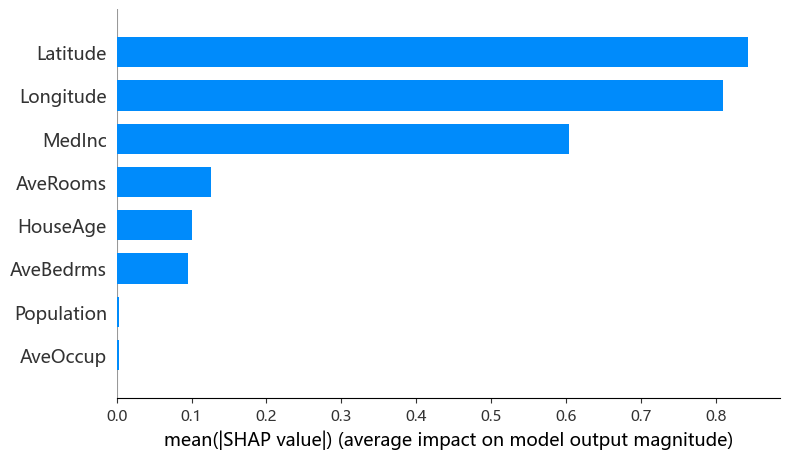

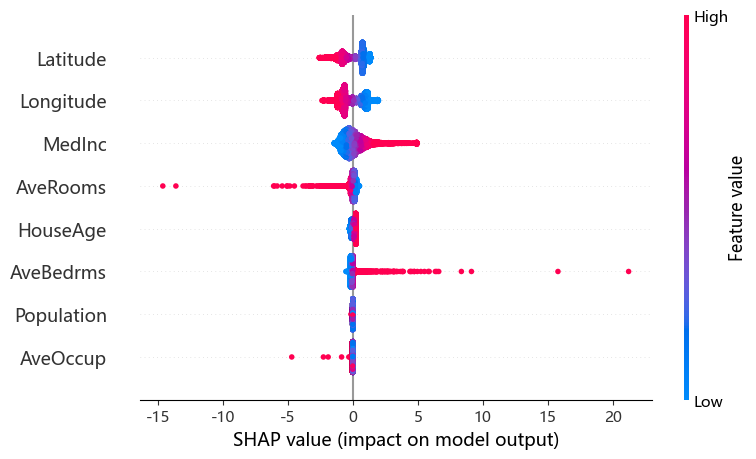

In [85]:
import shap

# 专属线性法
class StatsModelWrapper:
    def __init__(self, sm_model, feature_names):
        self.intercept_ = sm_model.params.iloc[0] # 取第一个参数（截距）
        self.coef_ = sm_model.params.iloc[1:].values # 剩余参数作为系数（转为 numpy 数组）
        self.feature_names = feature_names # 可选，便于可视化
modelwrapper = StatsModelWrapper(sm_model=model, feature_names=X.columns)
LR_explainer = shap.LinearExplainer(model=modelwrapper, masker=shap.maskers.Partition(X), link=shap.links.identity, nsamples=1000) # 构建shap解释器
LR_shap_values = LR_explainer.shap_values(X=X)
shap.summary_plot(LR_shap_values, X, plot_type="bar", show=True) # 全局特征重要性（平均绝对SHAP值）
shap.summary_plot(LR_shap_values, X, show=True) # SHAP散点图（显示特征值与SHAP值的关系，带颜色）

# shap.dependence_plot("Latitude", LR_shap_values, X) # 特定特征的依赖图（如Latitude）

# shap.plots.waterfall(shap.Explanation(
#     values=LR_shap_values[0],
#     base_values=LR_explainer.expected_value,
#     data=X.iloc[0],
#     feature_names=X.columns
# )) # 瀑布图（单样本分解，shap 0.40+版本）

# 模型无关法，与专属线性法结果一致
# def predict_fn(data):
#     data_const = sm.add_constant(data=data, prepend=True, has_constant="add") # 强制增加一列截距项
#     return model.predict(data_const)
# background = shap.sample(X=X, nsamples=100, random_state=42)
# K_explainer = shap.KernelExplainer(model=predict_fn, data=background, feature_names=X.columns, link="identity")
# K_shap_values = K_explainer.shap_values(X=X)
# plt.subplot(1, 2, 2)
# shap.summary_plot(K_shap_values, X, show=False) # 做出shap图
# plt.title("Kernel Explainer")

## 描述性统计分析

In [6]:
print(X.describe(percentiles=None, include=None, exclude=None).round(2))
print(Y.describe(percentiles=None, include=None, exclude=None).round(2))

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
50%       34.26    -118.49  
75%       37.71    -118.01  
max       41.95    -114.31  
       MedHouseVal
count     20640.00
mean          2.07
std           1.15
min           

## 直方图与KDE分布曲线
只有 MedInc 比较正态，其他的都右偏甚至严重

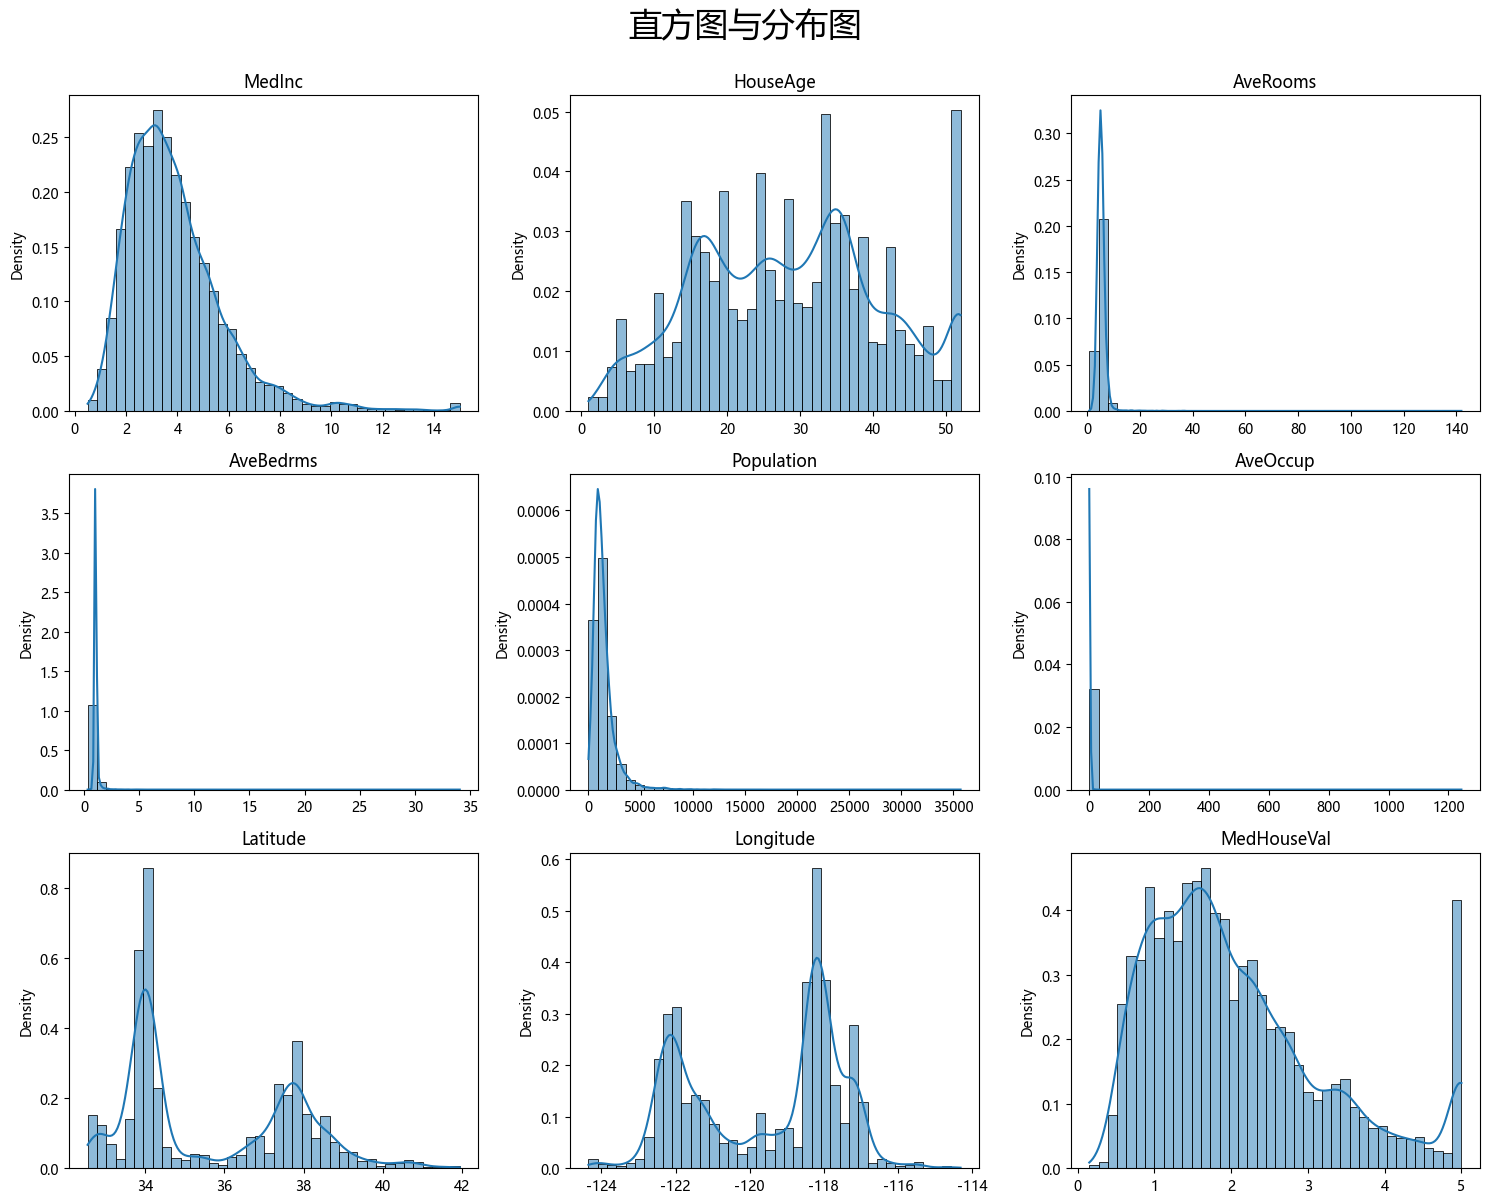

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
# 设置中文字体（如果系统支持）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Arial', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

all_data = pd.concat(objs=[X, Y], axis=1, join="outer", ignore_index=False, keys=None, levels=None, names=None, verify_integrity=False, sort=False)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
axes = axes.flatten()
for idx, col in enumerate(all_data.columns):
    sns.histplot(data=all_data, x=col, kde=True, bins=40, ax=axes[idx], stat="density")
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')
plt.suptitle(t="直方图与分布图", y=1, fontsize=24)
plt.tight_layout()
plt.show()

## 箱线图
HouseAge、Latitude、Longitude无异常值与极端值，其他的异常值和极端值较为严重

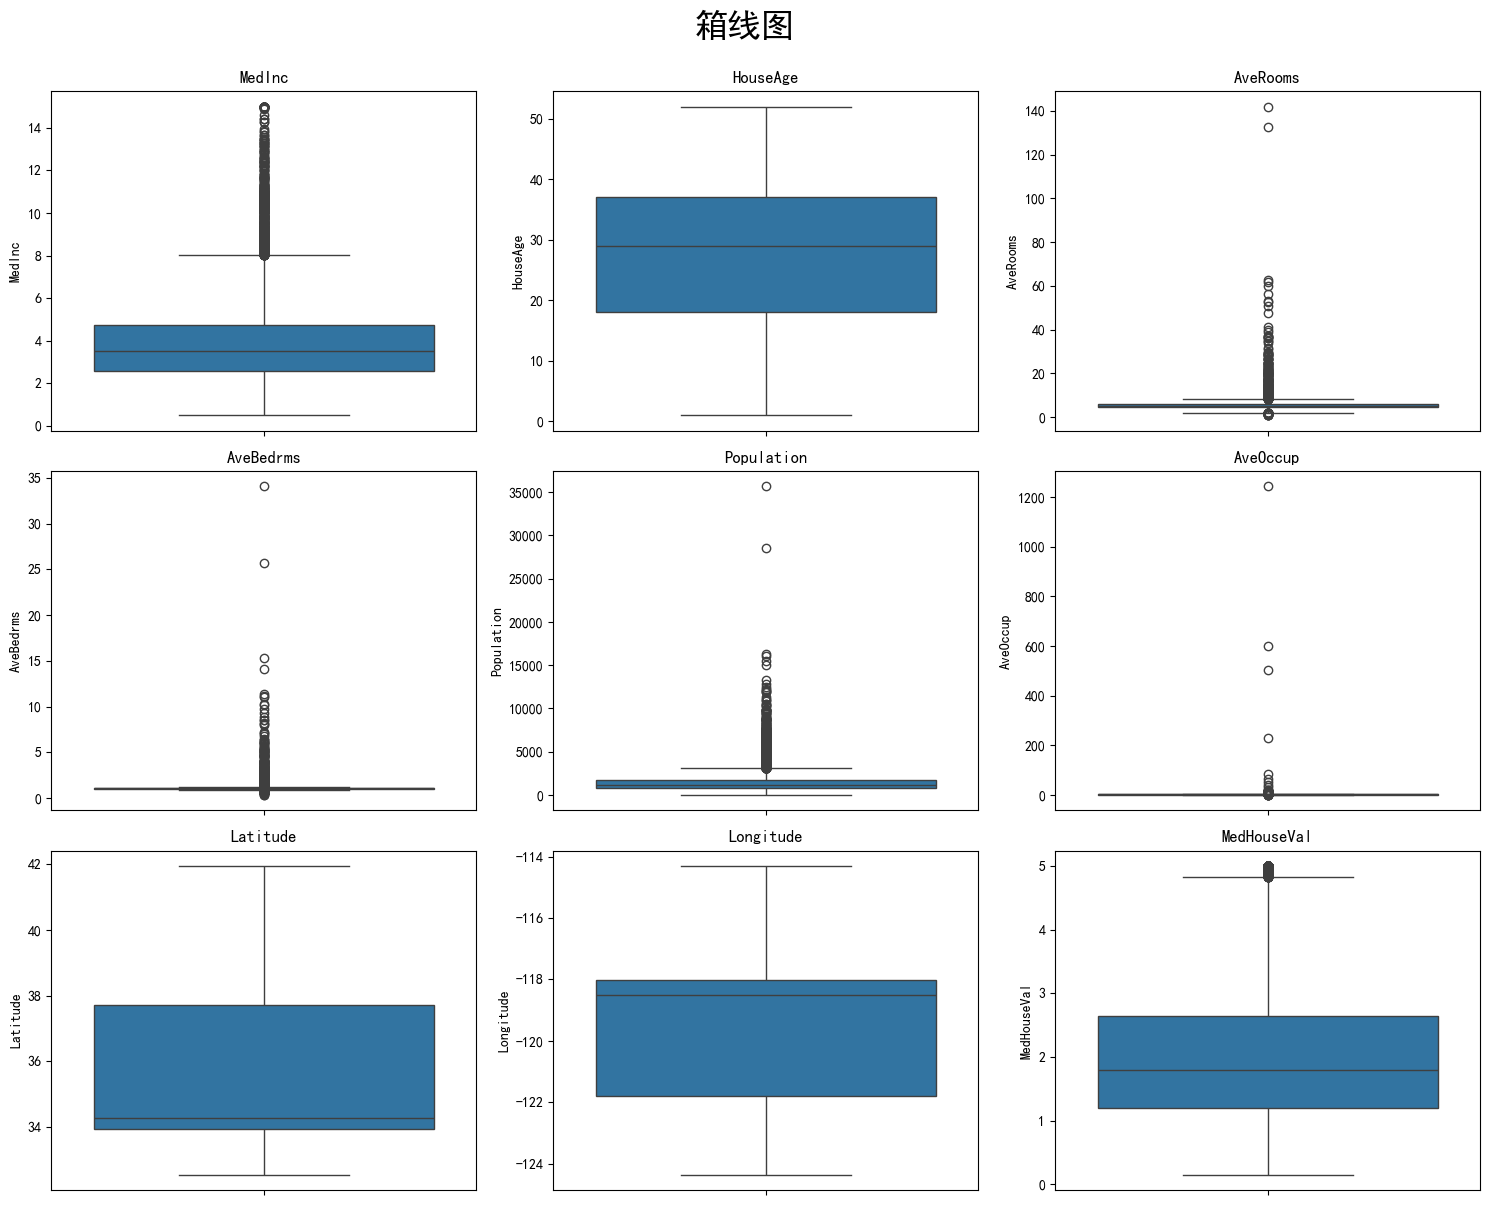

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
axes = axes.flatten()
for idx, col in enumerate(all_data.columns):
    sns.boxplot(data=all_data, y=col, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')
plt.suptitle(t="箱线图", y=1, fontsize=24)
plt.tight_layout()
plt.show()

## 散点图矩阵
看不出来具有线性关系

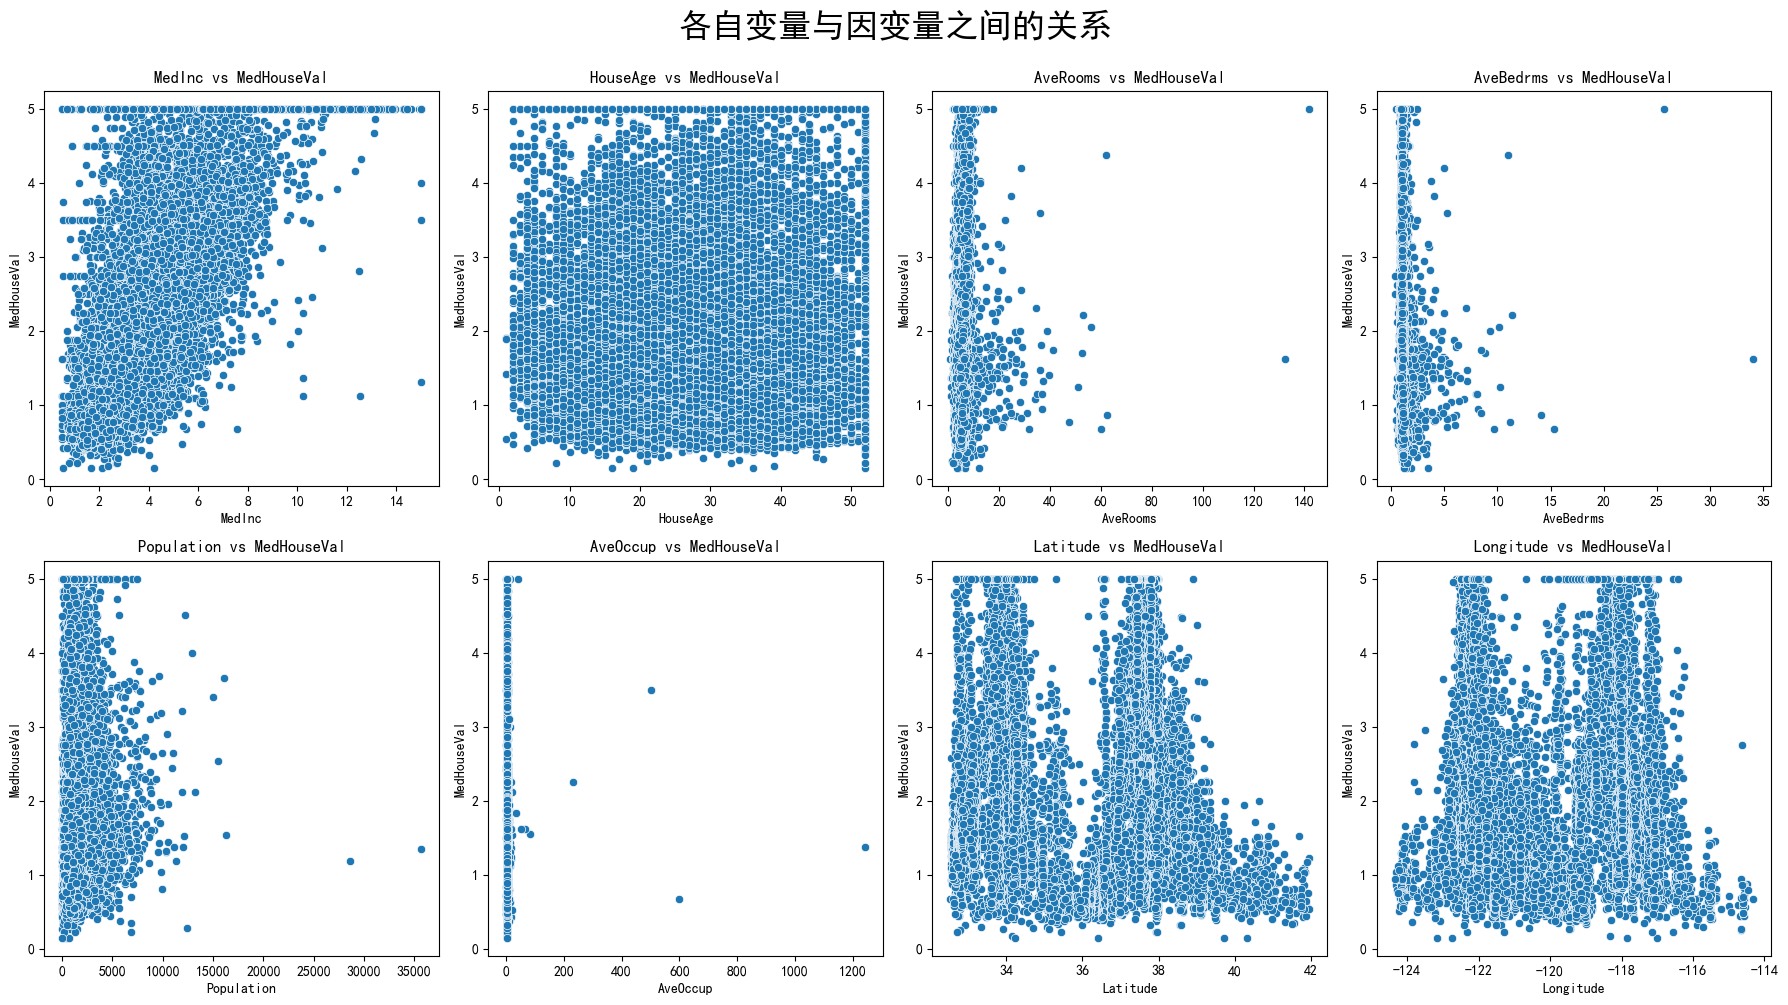

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,10))
axes = axes.flatten()
for idx, col in enumerate(X.columns):
    sns.scatterplot(data=all_data, x=col, y=all_data.columns[-1], ax=axes[idx])
    axes[idx].set_title(f"{col} vs {all_data.columns[-1]}")
    axes[idx].set_xlabel(col)
plt.suptitle(t="各自变量与因变量之间的关系", y=1, fontsize=24)
plt.tight_layout()
plt.show()

## 相关系数矩阵 + 热力图
皮尔逊相关系数（只记入绝对值大于0.2的）：
+ MedHouseVal与MedInc达到0.69，较高程度线性相关，其他的都比较低。<br>
+ AveRooms与AveBedrms达到0.85，高度线性相关；Latitude与Longitude达到-0.92，高度线性相关。
+ MedInc与AveRooms达到0.33，低程度线性相关；HouseAge与Population达到-0.30，低程度线性相关。

             MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc         1.00     -0.12      0.33      -0.06        0.00      0.02   
HouseAge      -0.12      1.00     -0.15      -0.08       -0.30      0.01   
AveRooms       0.33     -0.15      1.00       0.85       -0.07     -0.00   
AveBedrms     -0.06     -0.08      0.85       1.00       -0.07     -0.01   
Population     0.00     -0.30     -0.07      -0.07        1.00      0.07   
AveOccup       0.02      0.01     -0.00      -0.01        0.07      1.00   
Latitude      -0.08      0.01      0.11       0.07       -0.11      0.00   
Longitude     -0.02     -0.11     -0.03       0.01        0.10      0.00   
MedHouseVal    0.69      0.11      0.15      -0.05       -0.02     -0.02   

             Latitude  Longitude  MedHouseVal  
MedInc          -0.08      -0.02         0.69  
HouseAge         0.01      -0.11         0.11  
AveRooms         0.11      -0.03         0.15  
AveBedrms        0.07       0.01        -0.05  

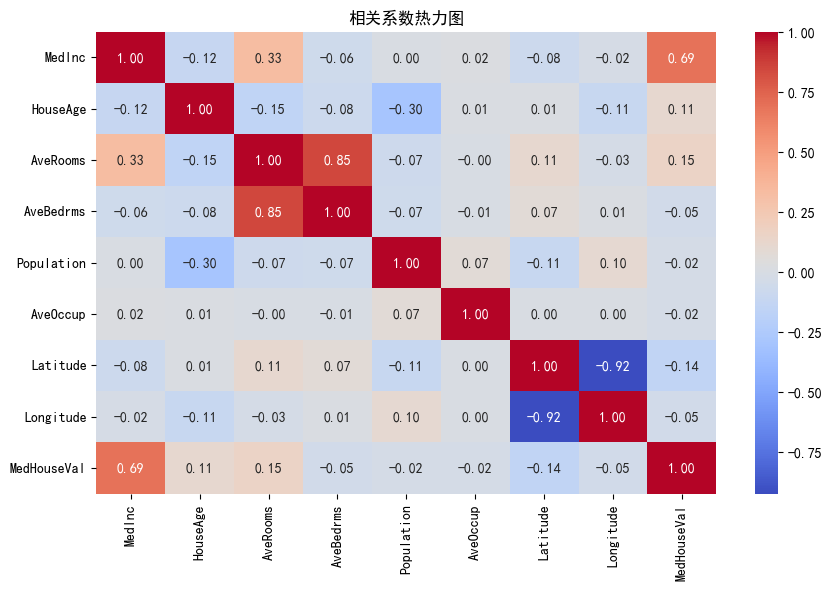

In [10]:
corr_matrix = all_data.corr(method="pearson", min_periods=1, numeric_only=False) # 计算相关系数矩阵
print(corr_matrix.round(2))

plt.figure(figsize=(10,6))
sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("相关系数热力图")
plt.show()

## VIF 计算
中度共线性：AveRooms、AveBedrms、Latitude、Longitude

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 

vif = pd.DataFrame()

# 和手动计算效果相同，只是需要去除截距项
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(exog=X_const.values, exog_idx=i)  for i in range(X_const.shape[1])]

# 不加截距项计算vif结果偏大，常用但不严格
# vif["feature"] = X.columns
# vif["VIF"] = [variance_inflation_factor(exog=X.values, exog_idx=i)  for i in range(X.shape[1])] 

# 手动计算效果太麻烦
# vif["feature"] = X.columns
# vif_values = []
# for i in range(X.shape[1]):
#     Y_vif = X.iloc[:,i]
#     X_other = X.drop(X.columns[i], axis=1)
#     X_other_const = sm.add_constant(data=X_other, prepend=True, has_constant="skip")
#     model = sm.OLS(Y_vif, X_other_const).fit()
#     r2 = model.rsquared
#     vif_values.append(1/(1-r2))
# vif["VIF"] = vif_values

print(vif.round(2))

      feature       VIF
0       const  17082.62
1      MedInc      2.50
2    HouseAge      1.24
3    AveRooms      8.34
4   AveBedrms      6.99
5  Population      1.14
6    AveOccup      1.01
7    Latitude      9.30
8   Longitude      8.96


## 经纬度散点图（颜色 = 房价）

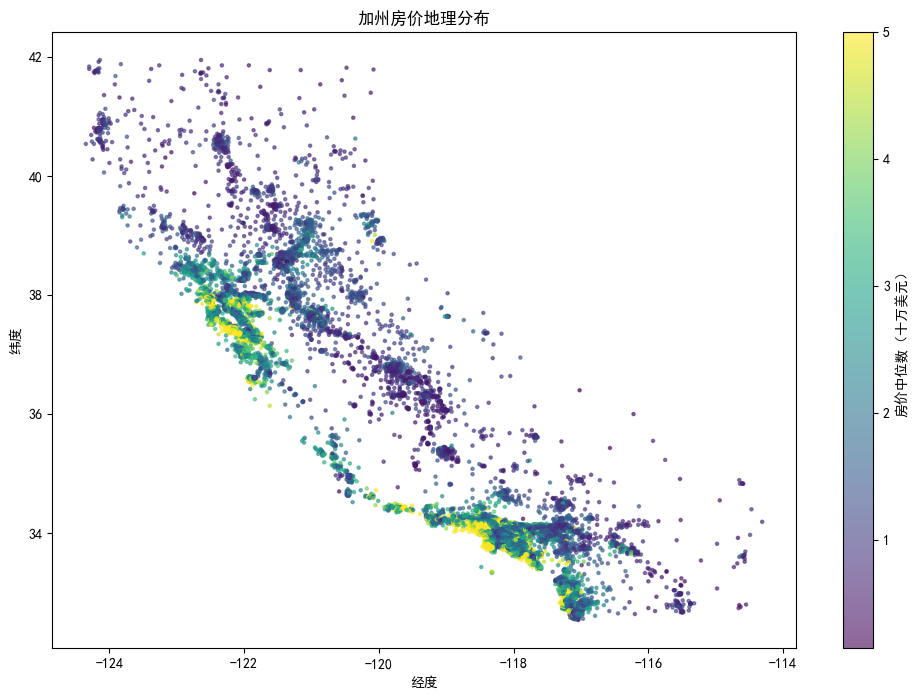

In [12]:
fig, axes = plt.subplots(figsize =(12, 8))

scatter = axes.scatter(x=X['Longitude'], y=X['Latitude'], c=Y["MedHouseVal"], cmap="viridis", s=5, alpha=0.6)
cbar = plt.colorbar(scatter, ax=axes) # 添加颜色调条
cbar.set_label('房价中位数（十万美元）')
axes.set_xlabel("经度")
axes.set_ylabel("纬度")
axes.set_title("加州房价地理分布")
plt.show()